<a href="https://colab.research.google.com/github/Samujjalborah/python-learning-journey/blob/main/Day_13_Restaurant_Branch_Performance_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 13 - Restaurant Branch Performance EDA

## Objective

This notebook performs an Exploratory Data Analysis (EDA) on the Restaurant Branch Performance dataset using Python, Pandas, Matplotlib, and Seaborn. The analysis explores the dataset through summary statistics, descriptive analysis, distribution analysis, grouping, and correlation analysis to identify meaningful business insights.

**Developed by:** Samujjal Borah

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)

In [ ]:
df = pd.read_csv("Restaurant_performance.csv")

In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 350
Columns : 22


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         350 non-null    object 
 1   Date              350 non-null    object 
 2   Day               350 non-null    object 
 3   Month             350 non-null    object 
 4   Branch            350 non-null    object 
 5   Region            350 non-null    object 
 6   Store_Type        350 non-null    object 
 7   Staff_Count       350 non-null    int64  
 8   Marketing_Spend   350 non-null    float64
 9   Customers         350 non-null    int64  
 10  Orders            350 non-null    int64  
 11  Average_Bill      350 non-null    float64
 12  Revenue           350 non-null    float64
 13  Food_Cost         350 non-null    float64
 14  Operating_Cost    350 non-null    float64
 15  Profit            350 non-null    float64
 16  Avg_Delivery_Min  350 non-null    float64
 1

In [ ]:
df.dtypes

,0
Record_ID,object
Date,object
Day,object
Month,object
Branch,object
Region,object
Store_Type,object
Staff_Count,int64
Marketing_Spend,float64
Customers,int64


In [ ]:
df.describe()

,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,11.957143,5516.347743,217.377143,187.054286,388.906371,86831.799657,31807.545114,56621.444486,30210.355171,26.098857,4.469314,27.740000,61.324571
std,4.338261,2050.906967,56.722524,50.558371,82.488196,36644.453901,13896.888942,18467.842215,19508.592192,4.388125,0.198258,4.903148,13.757322
min,5.000000,725.350000,77.000000,71.000000,180.000000,20540.760000,7262.010000,20782.380000,-6924.680000,13.900000,3.760000,14.500000,25.000000
25%,9.000000,4339.727500,180.250000,155.000000,337.315000,61261.717500,22326.662500,43797.670000,16915.492500,22.800000,4.320000,24.400000,51.325000
50%,11.000000,5393.370000,213.000000,182.500000,383.485000,79766.880000,28861.325000,53723.025000,26873.870000,26.100000,4.470000,27.800000,61.650000
75%,15.000000,6748.502500,255.750000,218.750000,441.765000,102976.185000,38370.370000,63961.227500,39823.742500,29.075000,4.600000,31.000000,70.375000
max,24.000000,11784.960000,360.000000,334.000000,623.280000,194018.920000,75946.590000,111489.140000,89096.190000,38.300000,4.960000,43.500000,95.000000


Missing Values

In [ ]:
missing[missing["Missing Values"]>0]

,Missing Values,Percentage
Promotion,184,52.571429


In [ ]:
df.columns

Index(['Record_ID', 'Date', 'Day', 'Month', 'Branch', 'Region', 'Store_Type',
       'Staff_Count', 'Marketing_Spend', 'Customers', 'Orders', 'Average_Bill',
       'Revenue', 'Food_Cost', 'Operating_Cost', 'Profit', 'Avg_Delivery_Min',
       'Customer_Rating', 'Temperature_C', 'Humidity_Percent', 'Weather',
       'Promotion'],
      dtype='object')

In [ ]:
df.nunique()

,0
Record_ID,350
Date,161
Day,7
Month,6
Branch,8
Region,3
Store_Type,3
Staff_Count,20
Marketing_Spend,350
Customers,178


Branch Performance

In [ ]:
branch_summary = (
    df.groupby("Branch")
      .agg(
          Records=("Revenue", "count"),
          Average_Revenue=("Revenue", "mean"),
          Total_Revenue=("Revenue", "sum"),
          Average_Profit=("Profit", "mean")
      )
      .sort_values("Average_Revenue", ascending=False)
)

branch_summary

,Records,Average_Revenue,Total_Revenue,Average_Profit
Branch,,,,
Bengaluru,46,90732.118696,4173677.46,31890.914783
Hyderabad,43,88804.899535,3818610.68,31402.976977
Pune,37,88107.489730,3259977.12,31265.571892
Delhi,32,87573.869375,2802363.82,31385.295313
Srinagar,52,86746.472885,4510816.59,30302.915769
Jaipur,48,86746.158333,4163815.60,30469.703333
Kochi,48,85574.617917,4107581.66,28902.036250
Mumbai,44,80779.248864,3554286.95,26580.988409


Region Performance

In [ ]:
region_summary = (
    df.groupby("Region")
      .agg(
          Records=("Profit", "count"),
          Average_Profit=("Profit", "mean"),
          Total_Profit=("Profit", "sum"),
          Average_Revenue=("Revenue", "mean")
      )
      .sort_values("Average_Profit", ascending=False)
)

region_summary

,Records,Average_Profit,Total_Profit,Average_Revenue
Region,,,,
South,137,30690.568102,4204607.83,88320.217518
North,132,30625.960833,4042626.83,86946.939470
West,81,28720.859877,2326389.65,84126.716914


Store type Performance

In [ ]:
store_summary = (
    df.groupby("Store_Type")
      .agg(
          Records=("Revenue", "count"),
          Average_Revenue=("Revenue", "mean"),
          Average_Profit=("Profit", "mean"),
          Average_Rating=("Customer_Rating", "mean")
      )
      .sort_values("Average_Revenue", ascending=False)
)

store_summary

,Records,Average_Revenue,Average_Profit,Average_Rating
Store_Type,,,,
Premium,52,152867.313269,62890.235385,4.458654
Standard,196,87268.667245,30630.785714,4.474388
Express,102,52327.164804,12742.137941,4.465000


Average Customer Rating by Branch

In [ ]:
df.groupby("Branch")["Customer_Rating"] \
  .mean() \
  .sort_values(ascending=False)

,Customer_Rating
Branch,
Pune,4.540811
Delhi,4.485625
Srinagar,4.480192
Hyderabad,4.469535
Jaipur,4.468958
Bengaluru,4.465652
Mumbai,4.442500
Kochi,4.419792


Revenue Distribution

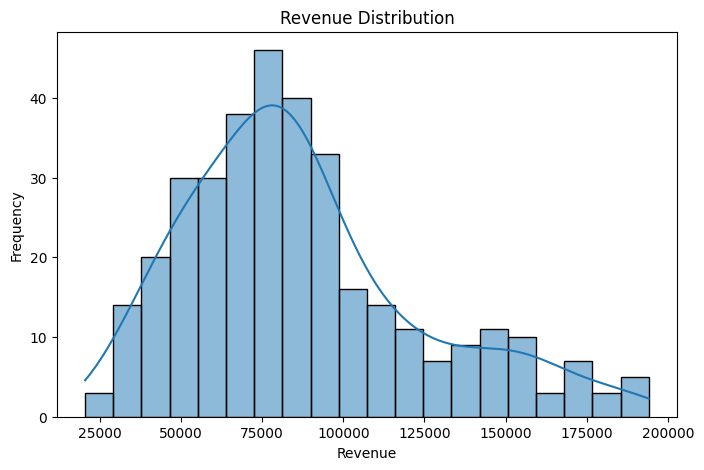

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Revenue"], bins=20, kde=True)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

Profit Distribution

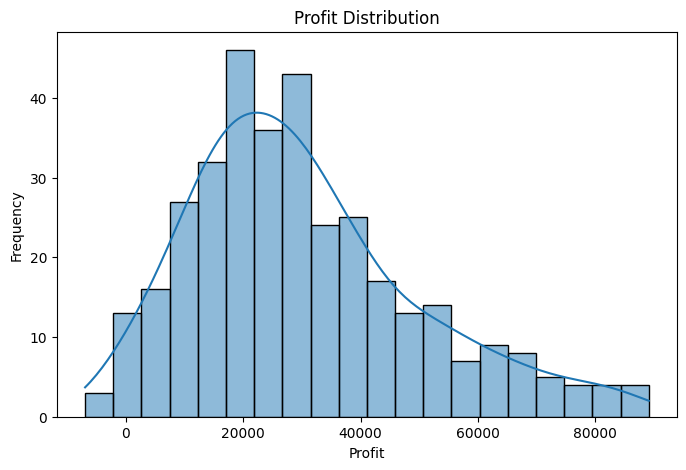

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Profit"], bins=20, kde=True)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

Customer Rating Distribution

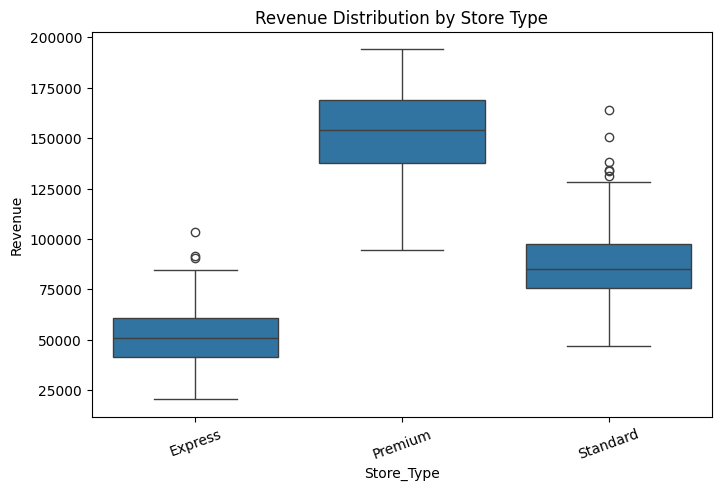

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Store_Type",
    y="Revenue"
)

plt.title("Revenue Distribution by Store Type")

plt.xticks(rotation=20)

plt.show()

Profit by Region

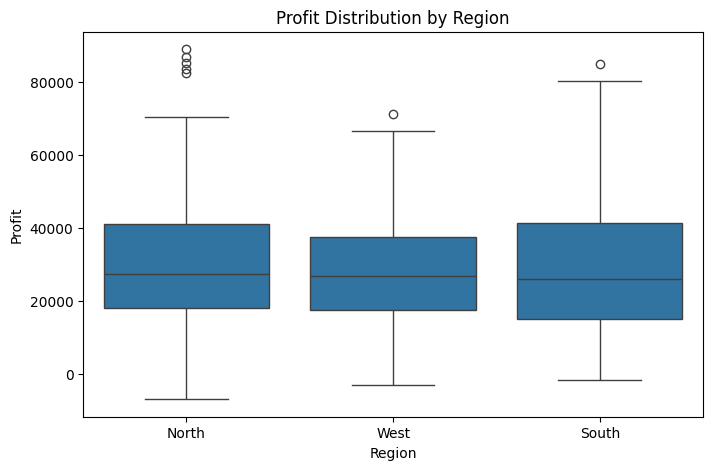

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Region",
    y="Profit"
)

plt.title("Profit Distribution by Region")

plt.show()

Correlation Matrix

In [27]:
numerical = df.select_dtypes(include="number")

corr_matrix = numerical.corr()

corr_matrix

,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
Staff_Count,1.000000,0.283133,0.689404,0.672229,0.521755,0.695114,0.680174,0.788468,0.559281,-0.182412,0.084284,0.083207,-0.017823
Marketing_Spend,0.283133,1.000000,0.405114,0.416349,0.332017,0.431136,0.404598,0.485469,0.350265,0.101244,-0.062082,0.058402,-0.045808
Customers,0.689404,0.405114,1.000000,0.980333,0.532218,0.876361,0.844339,0.855797,0.835993,0.183832,-0.048383,0.002476,-0.100527
Orders,0.672229,0.416349,0.980333,1.000000,0.522090,0.857756,0.827561,0.840780,0.815261,0.187107,-0.051216,0.020274,-0.094434
Average_Bill,0.521755,0.332017,0.532218,0.522090,1.000000,0.843033,0.836270,0.797641,0.828444,-0.033322,0.042172,-0.048566,-0.044084
Revenue,0.695114,0.431136,0.876361,0.857756,0.843033,1.000000,0.978581,0.962914,0.966831,0.078713,0.007942,-0.026119,-0.091142
Food_Cost,0.680174,0.404598,0.844339,0.827561,0.836270,0.978581,1.000000,0.972506,0.917517,0.077186,0.003235,-0.028036,-0.080084
Operating_Cost,0.788468,0.485469,0.855797,0.840780,0.797641,0.962914,0.972506,1.000000,0.862061,0.020431,0.021372,0.014333,-0.067680
Profit,0.559281,0.350265,0.835993,0.815261,0.828444,0.966831,0.917517,0.862061,1.000000,0.128512,-0.005314,-0.062630,-0.107130
Avg_Delivery_Min,-0.182412,0.101244,0.183832,0.187107,-0.033322,0.078713,0.077186,0.020431,0.128512,1.000000,-0.436984,0.004974,-0.112144


Correlation Heatmap

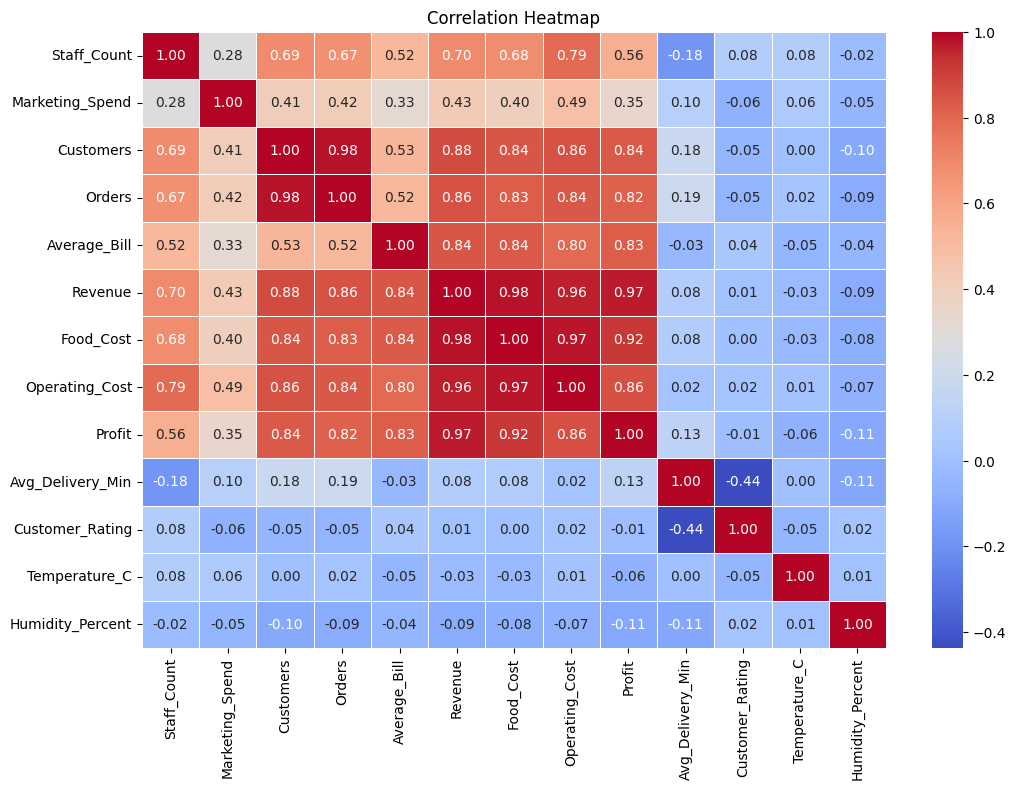

In [28]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [34]:
corr_matrix["Profit"].sort_values(ascending=False)

,Profit
Profit,1.000000
Revenue,0.966831
Food_Cost,0.917517
Operating_Cost,0.862061
Customers,0.835993
Average_Bill,0.828444
Orders,0.815261
Staff_Count,0.559281
Marketing_Spend,0.350265
Avg_Delivery_Min,0.128512


Revenue vs Profit

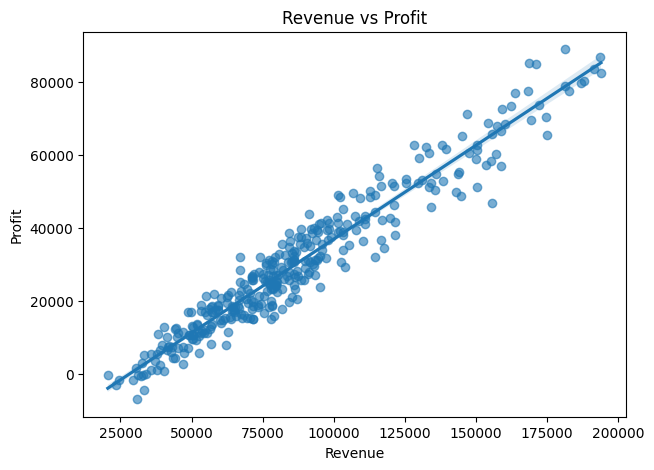

In [29]:
plt.figure(figsize=(7,5))

sns.regplot(
    data=df,
    x="Revenue",
    y="Profit",
    scatter_kws={"alpha":0.6}
)

plt.title("Revenue vs Profit")

plt.show()

Marketing Spend vs Revenue

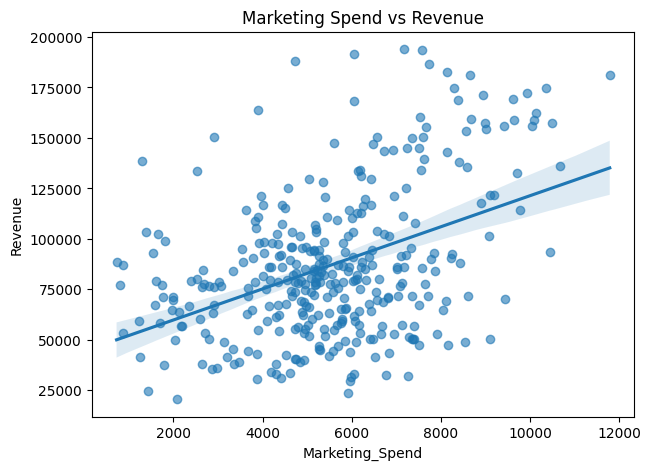

In [30]:
plt.figure(figsize=(7,5))

sns.regplot(
    data=df,
    x="Marketing_Spend",
    y="Revenue",
    scatter_kws={"alpha":0.6}
)

plt.title("Marketing Spend vs Revenue")

plt.show()

Delivery Time vs Rating

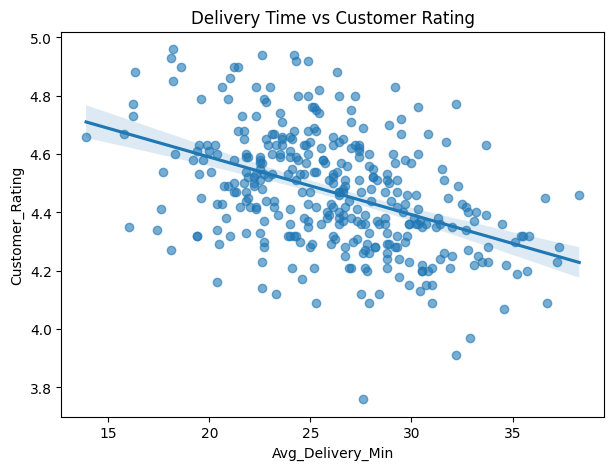

In [31]:
plt.figure(figsize=(7,5))

sns.regplot(
    data=df,
    x="Avg_Delivery_Min",
    y="Customer_Rating",
    scatter_kws={"alpha":0.6}
)

plt.title("Delivery Time vs Customer Rating")

plt.show()

Correlation Coefficients

In [32]:
print("Revenue vs Profit:",
      round(df["Revenue"].corr(df["Profit"]),3))

print("Marketing Spend vs Revenue:",
      round(df["Marketing_Spend"].corr(df["Revenue"]),3))

print("Delivery Time vs Customer Rating:",
      round(df["Avg_Delivery_Min"].corr(df["Customer_Rating"]),3))

Revenue vs Profit: 0.967
Marketing Spend vs Revenue: 0.431
Delivery Time vs Customer Rating: -0.437


In [33]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean() * 100, 2)
})

missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Percentage
Promotion,184,52.57


# Observations

- The dataset contains **350 restaurant performance records** with **22 variables**.
- The **Promotion** column has **184 missing values**, while all other columns contain complete data.
- **Premium** stores achieve the highest average revenue (≈152,867) and average profit (≈62,890), outperforming Standard and Express stores.
- **Bengaluru** records the highest average revenue among all branches (≈90,732), whereas **Mumbai** has the lowest average revenue (≈80,779).
- The **South** region has the highest average profit (≈30,691), followed closely by the North region.
- Revenue and Profit show a **very strong positive correlation (0.967)**, indicating that branches with higher revenue generally earn higher profits.
- Marketing Spend has a **moderate positive correlation (0.431)** with Revenue, suggesting an association between marketing investment and revenue, though this does **not** imply causation.
- Average Delivery Time has a **moderate negative correlation (-0.437)** with Customer Rating, indicating that longer delivery times are generally associated with lower customer ratings.

# Conclusion

The Restaurant Branch Performance dataset was explored using descriptive statistics, data inspection, grouping, distribution analysis, and correlation analysis. Premium stores demonstrated the strongest financial performance, while branch and regional analyses revealed differences in revenue and profitability. Correlation analysis showed a very strong positive relationship between revenue and profit, a moderate positive association between marketing spend and revenue, and a moderate negative relationship between delivery time and customer ratings. Overall, the exploratory analysis provides valuable insights into operational and financial performance that can support future business decision-making.